# Image Quality Evaluations of XCIST

The purpose of this is to validate the image quality of the XCIST simulator based on the IEC61223-3-5 for acceptance testing, these testes include:

| PROTOCOL ELEMENT | MEAN CT NUMBER                       | NOISE                                               | UNIFORMITY             |
|------------------|--------------------------------------|-----------------------------------------------------|------------------------|
| Adult Head       | Nominal value ± 4 HU (Small PHANTOM) | Nominal value ± max (15 %; 0,75 HU) (Small PHANTOM) | ≤ 4 HU (Small PHANTOM) |
| Adult Body       | Nominal value ± 6 HU (Large PHANTOM) | Nominal value ± max (15 %; 0,75 HU) (Large PHANTOM) | ≤ 8 HU (Large PHANTOM) |
| Paediatric Head  | Nominal value ± 4 HU (Small PHANTOM) | Nominal value ± max (15 %; 0,75 HU) (Small PHANTOM) | ≤ 4 HU (Small PHANTOM) |
| Paediatric Body  | Nominal value ± 4 HU (Small PHANTOM) | Nominal value ± max (15 %; 0,75 HU) (Small PHANTOM) | ≤ 4 HU (Small PHANTOM) |

Spatial Resolution, Artifacts, CTDI

In [1]:
import pydicom
import numpy as np

def read_dicom(dcm):
    assert(isinstance(dcm, pydicom.dataset.FileDataset))
    return dcm.pixel_array + dcm.RescaleIntercept
dcm = pydicom.read_file('/gpfs_projects/brandon.nelson/RSTs/pediatricIQphantoms/CTP404/diameter_350mm/350mm_CTP404_groundtruth.dcm')
img = read_dicom(dcm)
img = np.repeat(img[None], 200, axis=0)
img.shape

(200, 512, 512)

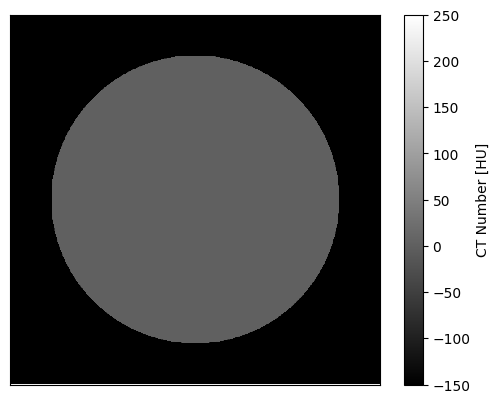

In [2]:
import matplotlib.pyplot as plt
from utils import ctshow, scrollview

img = np.zeros((512, 512))
nx, ny = img.shape
r = 200
for i in range(nx):
    for j in range(ny):
        img[i, j] = 1 if np.sqrt((i - nx/2)**2 + (j - ny/2)**2) < r else -1000
img = np.repeat(img[None], 200, axis=0)

im = ctshow(img)
plt.colorbar(im, label='CT Number [HU]')

In [3]:
from pedsilicoICH.image_acquisition import Scanner

In [4]:
from utils import get_effective_diameter

In [5]:
diameter_pixels = get_effective_diameter(img[0], 1)
known_diameter_mm = 200
fov_mm = img.shape[-1]*known_diameter_mm/diameter_pixels
fov_mm
dx = fov_mm/img.shape[-1]
dx

np.float64(0.5001088699623122)

In [6]:
from pedsilicoICH.ground_truth_definition.phantoms import Phantom
phantom = Phantom(img, spacings=3*[dx])

scanner = Scanner(phantom)

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.5001088699623122-mm pixels (XY), 0.5001088699623122-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 200 slices...
* Writing volume fraction files for 4 materials and 200 slices, plus the HU data...
* Writing def

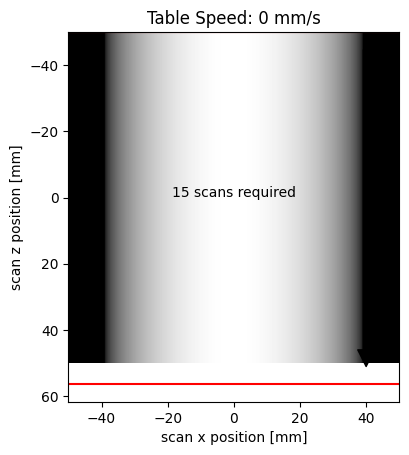

In [7]:
scanner.scout_view()

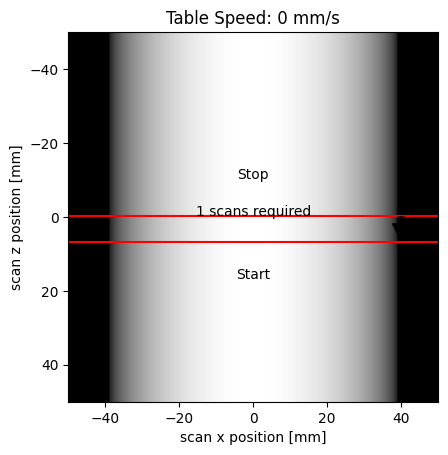

In [8]:
startZ, endZ = -5, 1
scanner.scout_view(startZ=startZ, endZ=endZ)

In [9]:
scanner.xcist.protocol.mA

200

## Slice thickness and recon kernel

In [10]:
scanner.run_scan(kVp=120, mA=200, startZ=startZ, endZ=endZ, views=100)

kernels = ['standard', 'soft']
thicknesses = [1, 5]

recons = []
conditions = []
for kernel in kernels:
    for thickness in  thicknesses:
        scanner.run_recon(sliceThickness=thickness, kernel=kernel)
        recons.append(scanner.recon[0])
        conditions.append(f'{kernel} {thickness} mm')

scan: 1/1
Airscan
Offset scan
Phantom scan


  0%|                                                                                                                                        | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    800 MB.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:33<00:00,  1.53s/it]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array t

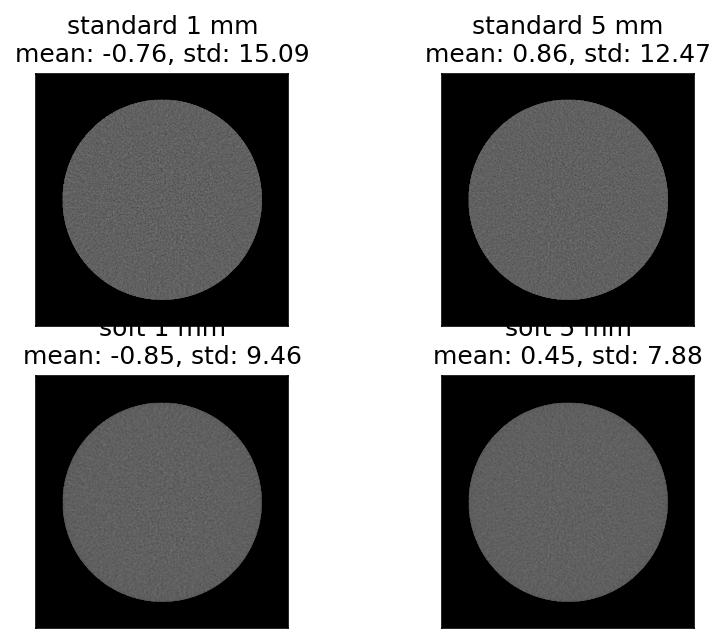

In [11]:
region = (240, 255), (200, 215)

fig, axs = plt.subplots(2,2, dpi=150)
for recon, condition, ax in zip(recons, conditions, axs.flatten()):
    ctshow(recon, fig=fig, ax=ax)
    roi = recon[region[0][0]:region[0][1], region[1][0]:region[1][1]]
    ax.set_title(condition + f'\nmean: {roi.mean():2.2f}, std: {roi.std():2.2f}')

## Beam Hardening Correction

In [12]:
conditions = [True, False, 'default']
recons = []

for condition in conditions:
    scanner = Scanner(phantom)
    scanner.run_scan(startZ=startZ, endZ=endZ, views=100, bhc=condition)
    scanner.run_recon()
    recons.append(scanner.recon[0])

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.5001088699623122-mm pixels (XY), 0.5001088699623122-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 200 slices...
* Writing volume fraction files for 4 materials and 200 slices, plus the HU data...
* Writing def

  0%|                                                                                                                                        | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    800 MB.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:34<00:00,  1.55s/it]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.5001088699623122-mm pixels (XY), 0.5001088699623122-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specifi

...

Prep view
Applying LSC...done.

Simulation is done.
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.5001088699623122-mm pixels (XY), 0.5001088699623122-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 

  0%|                                                                                                                                        | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    800 MB.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:49<00:00,  1.70s/it]


Prep view
Applying LSC...done.

Simulation is done.
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...


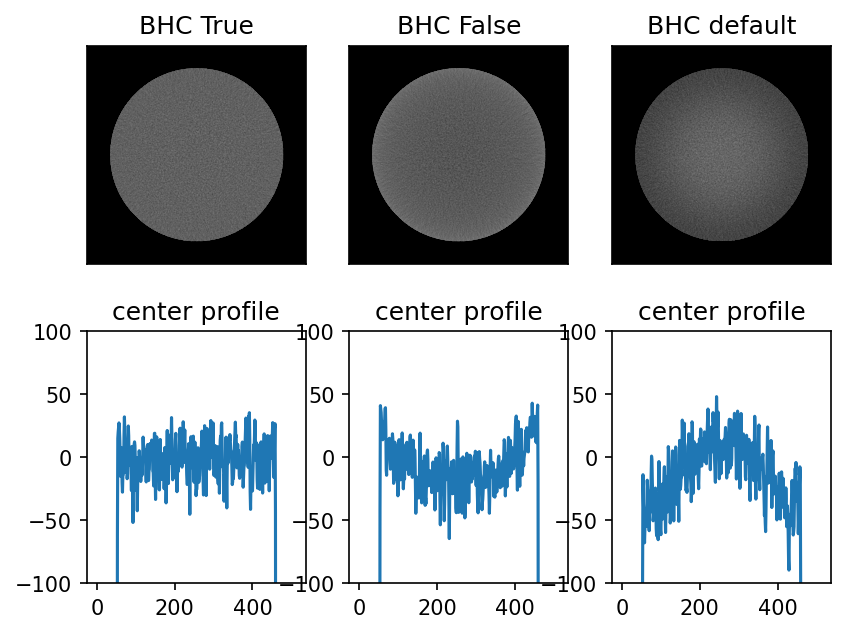

In [13]:
fig, axs = plt.subplots(2,3, dpi=150)

idx = 0
for recon, condition in zip(recons, conditions):
    ctshow(recon, (100, 0), fig=fig, ax=axs[0, idx])
    ctshow(recon, fig=fig, ax=axs[0, idx])
    axs[0, idx].set_title(f'BHC {condition}')
    axs[1, idx].plot(recon[256, :])
    axs[1, idx].set_ylim(-100, 100)
    axs[1, idx].set_title('center profile')
    idx += 1

## Noise vs mA level

looking for 1/sqrt(mA) behaviour, or variance = linear

In [14]:
from pathlib import Path
import os

In [15]:
mA_dir = Path('mA_test')
if mA_dir.exists():
    mA_dict = {}
    for mA in os.listdir(mA_dir):
        mA_dict[int(mA)] = np.stack([read_dicom(pydicom.read_file(o)) for o in (mA_dir / mA).glob('*.dcm')])
else:
    mA_dir.mkdir()
    views = 100
    mAs = np.linspace(10, 500, 10, dtype=int)
    recons = []
    for mA in mAs:
        scanner.run_scan(startZ=startZ, endZ=endZ, views=views, mA=mA)
        scanner.run_recon(sliceThickness=1)
        scanner.write_to_dicom(f'/{mA:03d}/{mA:03d}.dcm')
        recons.append(scanner.recon)
    mA_recons = np.stack(recons)
    mA_dict = dict(zip(mAs, mA_recons))

In [16]:
mA_dict.keys()

dict_keys([])

In [17]:
scrollview(mA_dict[10])

KeyError: 10

## Noise vs kVp level

In [ ]:
kV_dir = Path('kVp_test')
if kV_dir.exists():
    kVp_dict = {}
    for kV in os.listdir(kV_dir):
        kVp_dict[int(kV)] = np.stack([read_dicom(pydicom.read_file(o)) for o in (kV_dir / kV).glob('*.dcm')])
else:
    kV_dir.mkdir()
    kVps = np.arange(70, 140, 10, dtype=int)
    recons = []
    for kVp in kVps:
        scanner.run_scan(startZ=startZ, endZ=endZ, views=views, mA=500, kVp=kVp)
        scanner.run_recon(sliceThickness=1)
        scanner.write_to_dicom(f'{kV_dir} / {kVp:03d} / {kVp:03d}.dcm')
        recons.append(scanner.recon)
    kVp_recons = np.stack(recons)
    kVp_dict = dict(zip(kVps, kVp_recons))

In [ ]:
mA_dict.keys(), kVp_dict.keys()

In [ ]:
scrollview(kVp_dict[70])

In [ ]:
f, ax = plt.subplots(dpi=300)
sample_mAs = list(mA_dict.keys())[::4]
ctshow(np.concatenate([mA_dict[k][0] for k in sample_mAs], axis=1), fig=f, ax=ax)
ax.set_title(f'{sample_mAs} mA')

In [ ]:
f, ax = plt.subplots(dpi=300)
sample_kVs = list(kVp_dict.keys())[::3]
ctshow(np.concatenate([kVp_dict[k][0] for k in sample_kVs], axis=1), fig=f, ax=ax)
ax.set_title(f'{sample_kVs} kVp')